In [1]:
import os
os.environ["PYTHONHASHSEED"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
)

SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
# 0. Load data
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "dataset", "data.csv")

df = pd.read_csv(DATA_PATH) 
print(df.shape)
df.head()

(569, 32)


,ma_so,chan_doan,ban_kinh_trung_binh,ket_cau_trung_binh,chu_vi_trung_binh,dien_tich_trung_binh,do_tron_trung_binh,do_gon_trung_binh,do_lom_trung_binh,so_diem_lom_trung_binh,...,ban_kinh_toi_te_nhat,ket_cau_toi_te_nhat,chu_vi_toi_te_nhat,dien_tich_toi_te_nhat,do_tron_toi_te_nhat,do_gon_toi_te_nhat,do_lom_toi_te_nhat,so_diem_lom_toi_te_nhat,do_doi_xung_toi_te_nhat,chieu_fractal_toi_te_nhat
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# 1. Understand data
print(df.dtypes)
print(df.isna().mean())
df["chan_doan"].value_counts(normalize=True)
print(df["chan_doan"].unique())


ma_so                           int64
chan_doan                         str
ban_kinh_trung_binh           float64
ket_cau_trung_binh            float64
chu_vi_trung_binh             float64
dien_tich_trung_binh          float64
do_tron_trung_binh            float64
do_gon_trung_binh             float64
do_lom_trung_binh             float64
so_diem_lom_trung_binh        float64
do_doi_xung_trung_binh        float64
chieu_fractal_trung_binh      float64
ban_kinh_sai_so_chuan         float64
ket_cau_sai_so_chuan          float64
chu_vi_sai_so_chuan           float64
dien_tich_sai_so_chuan        float64
do_tron_sai_so_chuan          float64
do_gon_sai_so_chuan           float64
do_lom_sai_so_chuan           float64
so_diem_lom_sai_so_chuan      float64
do_doi_xung_sai_so_chuan      float64
chieu_fractal_sai_so_chuan    float64
ban_kinh_toi_te_nhat          float64
ket_cau_toi_te_nhat           float64
chu_vi_toi_te_nhat            float64
dien_tich_toi_te_nhat         float64
do_tron_toi_

In [4]:
# 2. Train/ split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["chan_doan"])
print("df_train :", df_train.shape, "df_test :", df_test.shape)
print("Ti le lop trong train:")
print(df_train["chan_doan"].value_counts(normalize=True))
print("\nTi le lop trong test:")
print(df_test["chan_doan"].value_counts(normalize=True))

df_train : (455, 32) df_test : (114, 32)
Ti le lop trong train:
chan_doan
B    0.626374
M    0.373626
Name: proportion, dtype: float64

Ti le lop trong test:
chan_doan
B    0.631579
M    0.368421
Name: proportion, dtype: float64


Thong ke mo ta
              ma_so  ban_kinh_trung_binh  ket_cau_trung_binh  \
count  4.550000e+02           455.000000          455.000000   
mean   3.305657e+07            14.166077           19.417692   
std    1.325805e+08             3.579081            4.290653   
min    8.670000e+03             6.981000            9.710000   
25%    8.690515e+05            11.710000           16.335000   
50%    9.059780e+05            13.340000           18.900000   
75%    8.910502e+06            15.935000           21.830000   
max    9.113205e+08            28.110000           39.280000   

       chu_vi_trung_binh  dien_tich_trung_binh  do_tron_trung_binh  \
count         455.000000            455.000000          455.000000   
mean           92.215868            659.578242            0.095993   
std            24.717118            360.418686            0.014310   
min            43.790000            143.500000            0.062510   
25%            75.235000            420.400000            

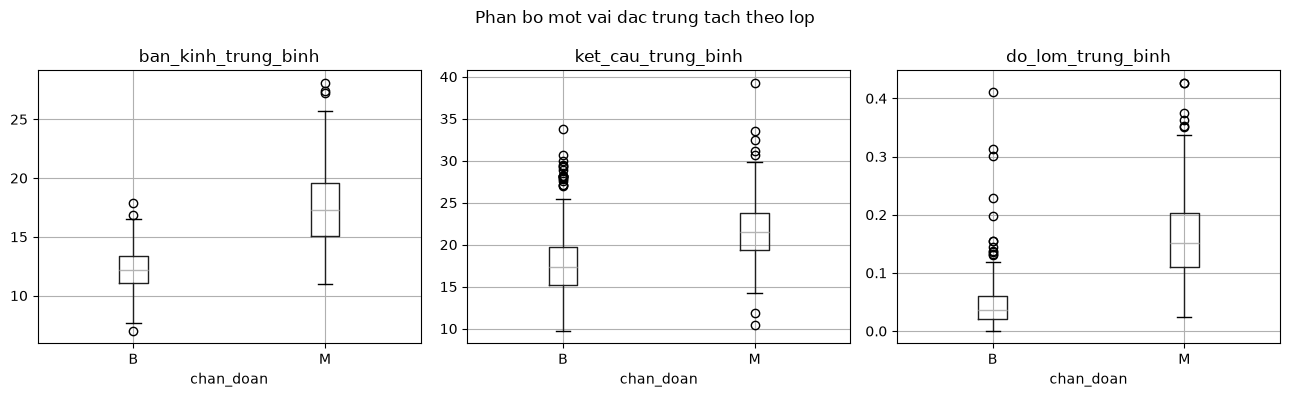

,ban_kinh_trung_binh,ket_cau_trung_binh,do_lom_trung_binh
ban_kinh_trung_binh,1.000000,0.326358,0.676323
ket_cau_trung_binh,0.326358,1.000000,0.292341
do_lom_trung_binh,0.676323,0.292341,1.000000


In [5]:
# EDA
print("Thong ke mo ta")
print(df_train.describe())

cac_cot_xem = ["ban_kinh_trung_binh", "ket_cau_trung_binh", "do_lom_trung_binh"]
df_train.groupby("chan_doan")[cac_cot_xem].mean()

fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, cot in zip(axes, cac_cot_xem):
    df.boxplot(column=cot, by="chan_doan", ax=ax)
    ax.set_title(cot)
    ax.set_xlabel("chan_doan")
plt.suptitle("Phan bo mot vai dac trung tach theo lop")
plt.tight_layout()
plt.show()

df_train[cac_cot_xem].corr()

In [6]:
# 4. clean data
print("So dong bi trung trong train:", df_train.duplicated().sum())
print("So dong bi trung trong test:", df_test.duplicated().sum())

df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

So dong bi trung trong train: 0
So dong bi trung trong test: 0


In [7]:
# 5. definn X vs y
cac_cot_dac_trung = [col for col in df_train if col if col not in ("ma_so", "chan_doan")]
print("Cac dac trung dua vao mo hinh:", cac_cot_dac_trung)
X_train = df_train[cac_cot_dac_trung]
y_train_raw = df_train["chan_doan"]

X_test = df_test[cac_cot_dac_trung]
y_test_raw = df_test["chan_doan"]

print(f"X_train : {X_train.shape}   y_train : {y_train_raw.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test_raw.shape}")

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
 
print("Anh xa nhan cua LabelEncoder:", dict(zip(le.classes_, le.transform(le.classes_))))

Cac dac trung dua vao mo hinh: ['ban_kinh_trung_binh', 'ket_cau_trung_binh', 'chu_vi_trung_binh', 'dien_tich_trung_binh', 'do_tron_trung_binh', 'do_gon_trung_binh', 'do_lom_trung_binh', 'so_diem_lom_trung_binh', 'do_doi_xung_trung_binh', 'chieu_fractal_trung_binh', 'ban_kinh_sai_so_chuan', 'ket_cau_sai_so_chuan', 'chu_vi_sai_so_chuan', 'dien_tich_sai_so_chuan', 'do_tron_sai_so_chuan', 'do_gon_sai_so_chuan', 'do_lom_sai_so_chuan', 'so_diem_lom_sai_so_chuan', 'do_doi_xung_sai_so_chuan', 'chieu_fractal_sai_so_chuan', 'ban_kinh_toi_te_nhat', 'ket_cau_toi_te_nhat', 'chu_vi_toi_te_nhat', 'dien_tich_toi_te_nhat', 'do_tron_toi_te_nhat', 'do_gon_toi_te_nhat', 'do_lom_toi_te_nhat', 'so_diem_lom_toi_te_nhat', 'do_doi_xung_toi_te_nhat', 'chieu_fractal_toi_te_nhat']
X_train : (455, 30)   y_train : (455,)
X_test  : (114, 30)    y_test  : (114,)
Anh xa nhan cua LabelEncoder: {'B': np.int64(0), 'M': np.int64(1)}


In [8]:
# 6. Preprocessinh
std_train = X_train.std(axis=0)
assert (std_train > 1e-12).all(), "co cot hang so - sinh ra nan"
print("khong co cot nao hang so")

imputer = SimpleImputer(strategy="median")
X_train_i = imputer.fit_transform(X_train)
X_test_i = imputer.transform(X_test)

scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_i)
X_test_c = scaler.transform(X_test_i)

print("Trung binh X_train_c (phai ~0):", np.round(X_train_c.mean(axis=0), 4))
print("Do lech chuan X_train_c (phai ~1):", np.round(X_train_c.std(axis=0), 4))

khong co cot nao hang so
Trung binh X_train_c (phai ~0): [-0.  0.  0. -0.  0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0. -0.
  0. -0. -0.  0. -0. -0. -0. -0. -0.  0. -0.  0.]
Do lech chuan X_train_c (phai ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


Mo hinh SGDClassifier — loss cuoi cung sau 100 epoch: 0.02644


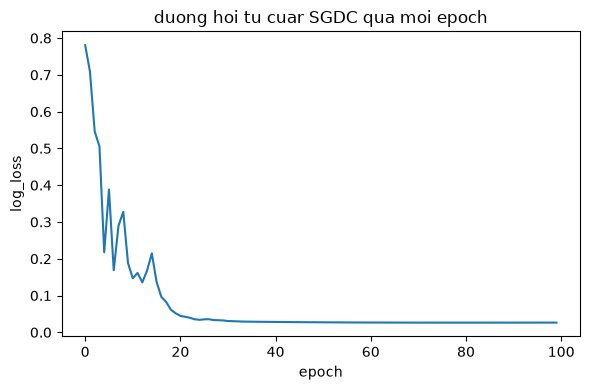

C tot nhat: 1.43845 theo macro-F1 CV: 0.9739
Diem baseline (DummyClassifier) macro-F1 CV: 0.3851
-> Mo hinh Logistic vuot ro rang baseline. OK.
[Huong A] Nguong tau tot nhat: 0.50 | macro-F1 (OOF): 0.9740


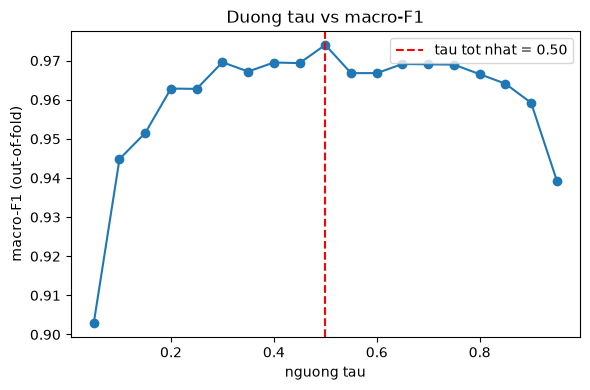

[Huong B] class_weight='balanced', tau=0.5 | macro-F1 CV: 0.9671
=> CHON HUONG A (dieu chinh nguong tau=0.50), diem A=0.9740 >= diem B=0.9671


In [22]:
# 7. Train + cross validation + regularization + compare + chon nguong
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

sgd = SGDClassifier(
    loss="log_loss", penalty="l2", alpha=1e-4,
    learning_rate="optimal", random_state=SEED
)
so_epoch = 100
lich_su_loss = []
cac_lop = np.array([0,1])

for _ in range(so_epoch):
    sgd.partial_fit(X_train_c, y_train, classes=cac_lop)
    proba = sgd.predict_proba(X_train_c,)[:, 1]
    loss = log_loss(y_train, proba)
    lich_su_loss.append(loss)

print("Mo hinh SGDClassifier — loss cuoi cung sau", so_epoch, "epoch:", round(lich_su_loss[-1], 6))

plt.figure(figsize=(6,4))
plt.plot(lich_su_loss)
plt.xlabel("epoch")
plt.ylabel("log_loss")
plt.title("duong hoi tu cuar SGDC qua moi epoch")
plt.tight_layout()
plt.show()
plt.close()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(
    LogisticRegression(),
    param_grid={"C": np.logspace(-3,3,20)},
    scoring="f1_macro", cv=skf,
)

grid.fit(X_train_c, y_train)
C_tot_nhat = grid.best_params_["C"]
print(f"C tot nhat: {C_tot_nhat:.5f} theo macro-F1 CV: {grid.best_score_:.4f}")

# so voi baseline (Dummy classifer: mo hinh khong hoc gi)
baseline = DummyClassifier(strategy="most_frequent")
diem_baseline = cross_val_score(baseline, X_train_c, y_train, scoring="f1_macro", cv=skf).mean()
print(f"Diem baseline (DummyClassifier) macro-F1 CV: {diem_baseline:.4f}")
 
assert grid.best_score_ > diem_baseline, "Mo hinh chua vuot baseline — kiem tra lai pipeline!"
print("-> Mo hinh Logistic vuot ro rang baseline. OK.")

# Chon nguong t qua xac suat out-of-fold (Huong A)
mo_hinh_A = LogisticRegression(C=C_tot_nhat, max_iter=5000)
proba_oof_A = cross_val_predict(mo_hinh_A, X_train_c, y_train, cv=skf, method="predict_proba")[:, 1]
 
ket_qua_tau = []
for tau in np.linspace(0.05, 0.95, 19):
    y_pred_oof = (proba_oof_A >= tau).astype(int)
    f1 = f1_score(y_train, y_pred_oof, average="macro", labels=[0, 1])
    ket_qua_tau.append((tau, f1))
 
tau_tot_nhat, diem_A = max(ket_qua_tau, key=lambda t: t[1])
print(f"[Huong A] Nguong tau tot nhat: {tau_tot_nhat:.2f} | macro-F1 (OOF): {diem_A:.4f}")
 
# %%
taus, f1s = zip(*ket_qua_tau)
plt.figure(figsize=(6, 4))
plt.plot(taus, f1s, marker="o")
plt.axvline(tau_tot_nhat, color="red", linestyle="--", label=f"tau tot nhat = {tau_tot_nhat:.2f}")
plt.xlabel("nguong tau")
plt.ylabel("macro-F1 (out-of-fold)")
plt.title("Duong tau vs macro-F1")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

mo_hinh_B = LogisticRegression(C=C_tot_nhat, max_iter=5000, class_weight="balanced")
diem_B = cross_val_score(mo_hinh_B, X_train_c, y_train, scoring="f1_macro", cv=skf).mean()
print(f"[Huong B] class_weight='balanced', tau=0.5 | macro-F1 CV: {diem_B:.4f}")
 
if diem_A >= diem_B:
    huong_chon = "A"
    print(f"=> CHON HUONG A (dieu chinh nguong tau={tau_tot_nhat:.2f}), "
          f"diem A={diem_A:.4f} >= diem B={diem_B:.4f}")
else:
    huong_chon = "B"
    print(f"=> CHON HUONG B (class_weight='balanced'), "
          f"diem B={diem_B:.4f} > diem A={diem_A:.4f}")

In [ ]:
# 8. Chot mo hinh cuoi cung
if huong_chon == "A":
    mo_hinh_cuoi = LogisticRegression(C=C_tot_nhat, max_iter=5000)
    tau_dung = tau_tot_nhat
else:
    mo_hinh_cuoi = LogisticRegression(C=C_tot_nhat, max_iter=5000, class_weight="balanced")
    tau_dung = 0.5
 
mo_hinh_cuoi.fit(X_train_c, y_train)
print(f"Da huan luyen mo hinh cuoi voi C={C_tot_nhat:.5f}, huong={huong_chon}, tau_dung={tau_dung:.2f}")

Da huan luyen mo hinh cuoi voi C=1.43845, huong=A, tau_dung=0.50


In [24]:
#9. Predict tren tap TEST
proba_test = mo_hinh_cuoi.predict_proba(X_test_c)[:, 1]
y_pred = (proba_test >= tau_dung).astype(int)
print(f"Da du doan {len(y_pred)} mau tren tap test, dung tau_dung={tau_dung:.2f}")

Da du doan 114 mau tren tap test, dung tau_dung=0.50


In [25]:
#10. Evaluate
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro", labels=[0, 1])
auc = roc_auc_score(y_test, proba_test)
 
print(f"Accuracy : {acc:.4f}")
print(f"Macro-F1 : {macro_f1:.4f}  (so voi baseline CV: {diem_baseline:.4f})")
print(f"ROC-AUC  : {auc:.4f}")
 
confusion_matrix(y_test, y_pred)
 
print(classification_report(
    y_test, y_pred, labels=[0, 1], target_names=["lanh tinh (0)", "ac tinh (1)"]
))

Accuracy : 0.9737
Macro-F1 : 0.9716  (so voi baseline CV: 0.3851)
ROC-AUC  : 0.9947
               precision    recall  f1-score   support

lanh tinh (0)       0.97      0.99      0.98        72
  ac tinh (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



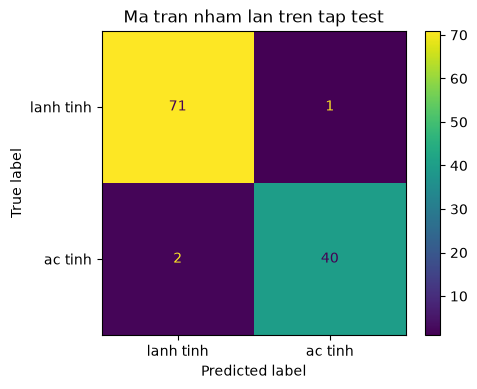

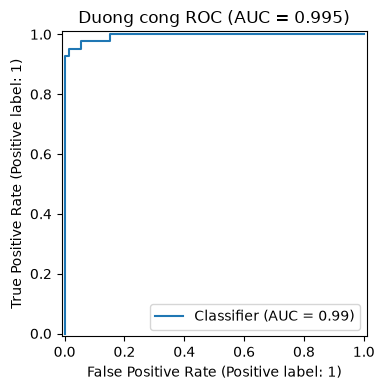

In [27]:
# Buoc 11. Visualization

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, display_labels=["lanh tinh", "ac tinh"]
)
ax.set_title("Ma tran nham lan tren tap test")
plt.tight_layout()
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, proba_test, ax=ax)
ax.set_title(f"Duong cong ROC (AUC = {auc:.3f})")
plt.tight_layout()
plt.show()
plt.close()